# **Klasifikasi Penyakit Daun Padi Menggunakan Ekstraksi Fitur MobileNetV3 dan Random Forest untuk Mendukung Pertanian Berkelanjutan**

**Topik:**  
Pangan

**Rumusan Masalah:**  
1.3 Dampak Perubahan Iklim dan Rendahnya Adopsi Pertanian Berkelanjutan

## **Anggota Tim**

1. Fina Nihayatul Husna (24031554022)
2. Juli Yawati Manalu (24031554050)
3. Alya Nabila Tamam (24031554099)

## **Dataset**

Dataset yang digunakan berasal dari Kaggle:

**Sumber Dataset:**  
https://www.kaggle.com/datasets/alamshihab075/rice-leaf-disease-an-images-dataset

Dataset terdiri dari **18 kelas** penyakit daun padi yang mencakup berbagai jenis penyakit akibat bakteri, jamur, virus, hama, serta kondisi tanaman sehat.


# Import Library

In [ ]:
import os
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,
    load_img
)

from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

# Load Folder dari Kaggle

In [ ]:
path = kagglehub.dataset_download(
    "alamshihab075/rice-leaf-disease-an-images-dataset"
)

print("Dataset berhasil di-download!")
print("Lokasi dataset:", path)

100%|██████████| 9.63G/9.63G [02:00<00:00, 86.1MB/s]

Extracting files...


Dataset berhasil di-download!
Lokasi dataset: /root/.cache/kagglehub/datasets/alamshihab075/rice-leaf-disease-an-images-dataset/versions/1


## Cek Folder

In [ ]:
for root, dirs, files in os.walk(path):
    print("Folder:", root)
    print("Subfolder:", dirs)
    break

Folder: /root/.cache/kagglehub/datasets/alamshihab075/rice-leaf-disease-an-images-dataset/versions/1
Subfolder: ['Rice Disease']


# Load Dataset

In [ ]:
DATASET_DIR = os.path.join(path, "Rice Disease")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print(DATASET_DIR)
print(os.listdir(DATASET_DIR))

/root/.cache/kagglehub/datasets/alamshihab075/rice-leaf-disease-an-images-dataset/versions/1/Rice Disease
['Sheath Blight', 'Tungro', 'Leaf Smut', 'Grassy Stunt Virus', 'Leaf Blast', 'Ragged Stunt Virus', 'Bacterial Blight', 'Stem Rot', 'Narrow Brown Spot', 'Healthy', 'Bakanae', 'Brown Spot', 'Leaf Scald', 'Bacterial Streak', 'Neck Blast', 'False Smut', 'Sheath Rot', 'Hispa']


##DataFrame File dan Label

In [ ]:
filepaths = []
labels = []

for label in os.listdir(DATASET_DIR):

    class_dir = os.path.join(DATASET_DIR, label)

    if os.path.isdir(class_dir):

        for file in os.listdir(class_dir):

            filepaths.append(
                os.path.join(class_dir, file)
            )

            labels.append(label)

df = pd.DataFrame({
    'filename': filepaths,
    'label': labels
})
print(df.head())

print("\nTotal Data :", len(df))

                                            filename          label
0  /root/.cache/kagglehub/datasets/alamshihab075/...  Sheath Blight
1  /root/.cache/kagglehub/datasets/alamshihab075/...  Sheath Blight
2  /root/.cache/kagglehub/datasets/alamshihab075/...  Sheath Blight
3  /root/.cache/kagglehub/datasets/alamshihab075/...  Sheath Blight
4  /root/.cache/kagglehub/datasets/alamshihab075/...  Sheath Blight

Total Data : 29363


Dataset berhasil dibaca dan disusun ke dalam DataFrame dengan dua kolom, yaitu filename dan label. Total dataset yang digunakan sebanyak 29.363 citra daun padi dari berbagai kelas penyakit.

# Exploratory Data Analysis (EDA)

Sheath Blight: 632
Tungro: 3228
Leaf Smut: 1500
Grassy Stunt Virus: 100
Leaf Blast: 3456
Ragged Stunt Virus: 100
Bacterial Blight: 4248
Stem Rot: 100
Narrow Brown Spot: 1808
Healthy: 2952
Bakanae: 100
Brown Spot: 4661
Leaf Scald: 2608
Bacterial Streak: 99
Neck Blast: 1322
False Smut: 149
Sheath Rot: 91
Hispa: 2209


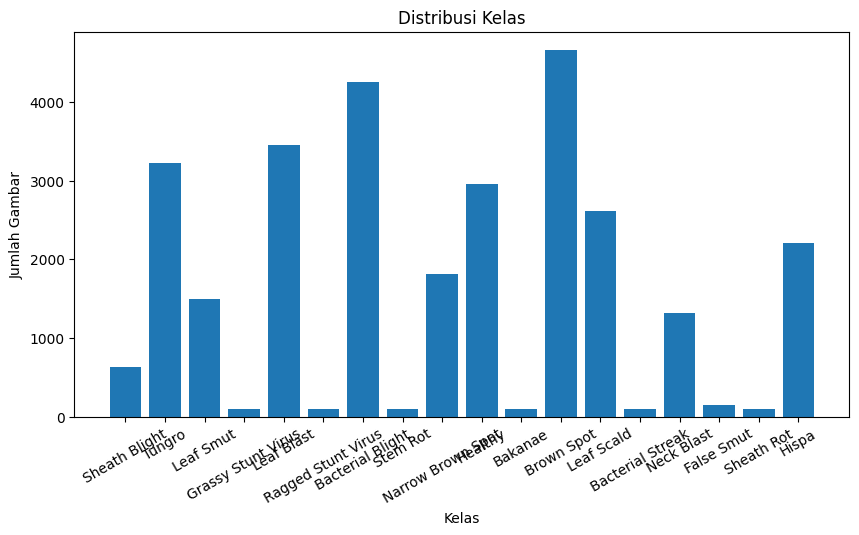

In [ ]:
class_counts = {}
for cls in os.listdir(DATASET_DIR):
    cls_path = os.path.join(DATASET_DIR, cls)
    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        class_counts[cls] = count
        print(f"{cls}: {count}")

plt.figure(figsize=(10,5))
plt.bar(
    class_counts.keys(),
    class_counts.values()
)

plt.title("Distribusi Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")

plt.xticks(rotation=30)

plt.show()

Berdasarkan hasil EDA, diketahui bahwa jumlah data pada setiap kelas tidak seimbang. Kelas Brown Spot dan Bacterial Blight memiliki jumlah citra paling banyak, sedangkan beberapa kelas lain seperti Sheath Rot, Bacterial Streak, dan Bakanae memiliki jumlah data yang sangat sedikit. Kondisi ini menunjukkan adanya class imbalance yang dapat mempengaruhi performa model klasifikasi. Oleh karena itu, penelitian ini hanya menggunakan lima kelas penyakit dengan jumlah data terbanyak, yaitu Brown Spot, Bacterial Blight, Leaf Blast, Tungro, dan Leaf Scald, serta satu kelas Healthy sebagai pembanding tanaman yang tidak terinfeksi penyakit. Pemilihan kelas-kelas tersebut dilakukan untuk mengurangi tingkat ketidakseimbangan data dan memastikan setiap kelas memiliki jumlah sampel yang memadai untuk proses pelatihan dan evaluasi model.

## Pengambilan 5 Kelas Penyakit Terbanyak dan Kelas Healthy

In [ ]:
selected_classes = [
    'Brown Spot',
    'Bacterial Blight',
    'Leaf Blast',
    'Tungro',
    'Leaf Scald',
    'Healthy'
]

df = df[df['label'].isin(selected_classes)].copy()

print(df['label'].value_counts())
print("Jumlah kelas:", df['label'].nunique())

label
Brown Spot          4661
Bacterial Blight    4248
Leaf Blast          3456
Tungro              3228
Healthy             2952
Leaf Scald          2608
Name: count, dtype: int64
Jumlah kelas: 6


## Sampel Citra

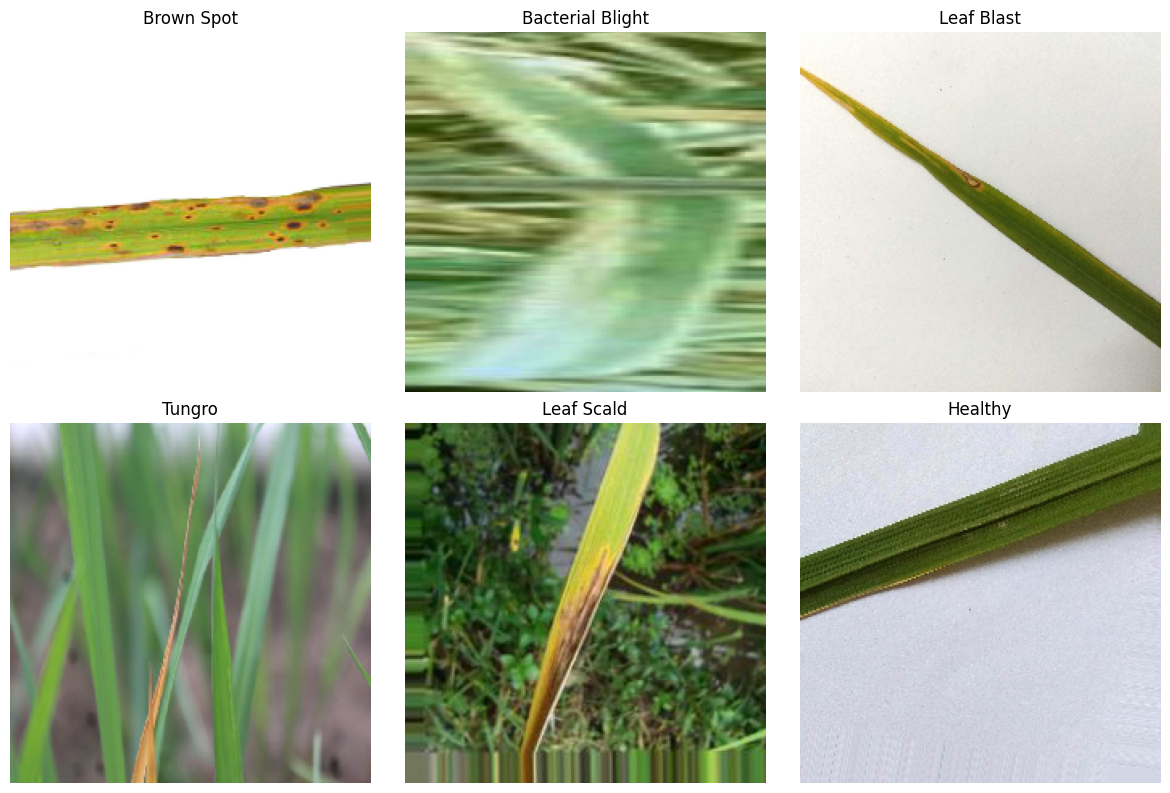

In [ ]:
classes = selected_classes

plt.figure(figsize=(12,8))

for i, cls in enumerate(classes[:6]):

    img_name = os.listdir(os.path.join(DATASET_DIR, cls))[0]
    img_path = os.path.join(DATASET_DIR, cls, img_name)
    img = load_img(img_path, target_size=IMG_SIZE)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Stratified Split

In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=42
)

print("Train :", len(train_df))
print("Val   :", len(val_df))
print("Test  :", len(test_df))

Train : 14807
Val   : 3173
Test  : 3173


Dataset berhasil dibagi menggunakan metode stratified split dengan proporsi 70% data latih, 15% data validasi, dan 15% data uji.

# Augmentasi Data

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    shear_range=0.1,
    brightness_range=[0.8,1.2]
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

## Visualisasi Augmentasi

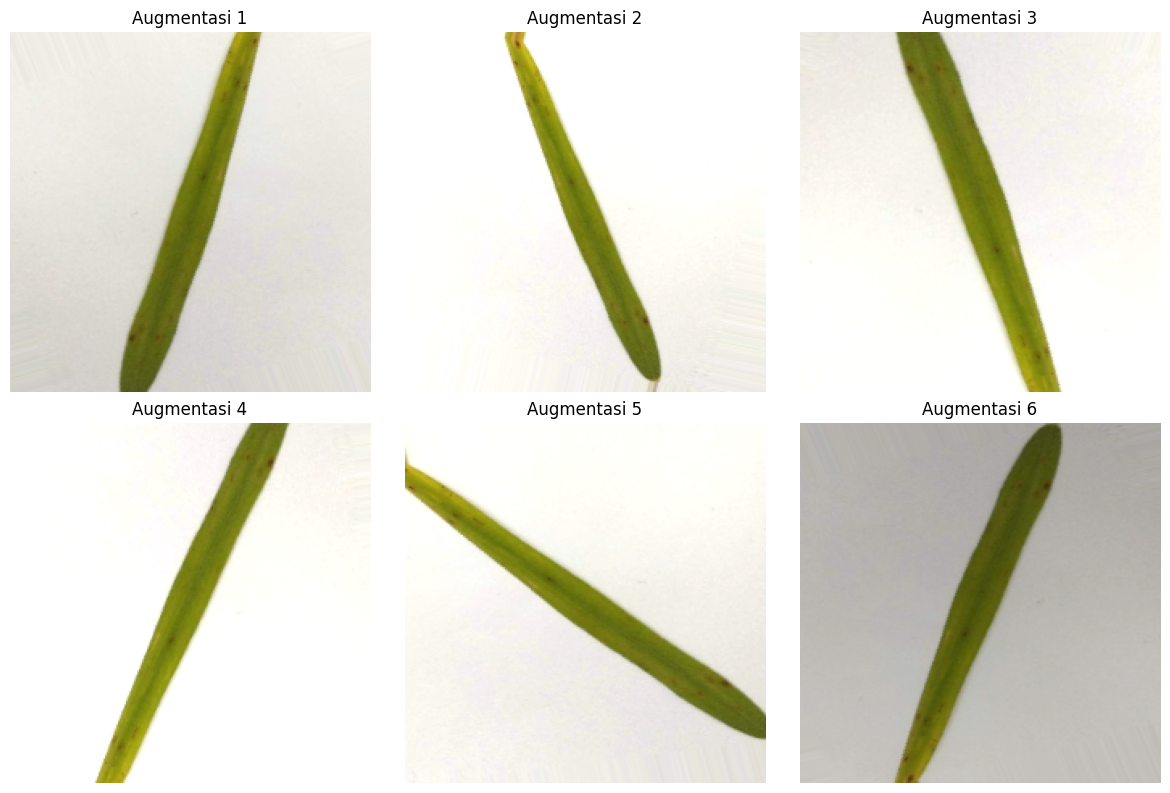

In [ ]:
sample_img = train_df.iloc[0]['filename']
img = load_img(sample_img, target_size=IMG_SIZE)
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
augment_iter = train_datagen.flow(img_array, batch_size=1)
plt.figure(figsize=(12,8))

for i in range(6):
    aug_img = next(augment_iter)[0].astype('uint8')
    plt.subplot(2,3,i+1)
    plt.imshow(aug_img)
    plt.axis("off")
    plt.title(f"Augmentasi {i+1}")

plt.tight_layout()

plt.show()

Visualisasi augmentasi menunjukkan bahwa citra mengalami berbagai transformasi seperti rotasi, flipping, zoom, shear, dan perubahan brightness.

# Generator

In [ ]:
train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filename',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

val_gen = test_datagen.flow_from_dataframe(
    val_df,
    x_col='filename',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

test_gen = test_datagen.flow_from_dataframe(
    test_df,
    x_col='filename',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

class_names = list(train_gen.class_indices.keys())

print(class_names)

print("\nJumlah Class :", len(class_names))

Found 14807 validated image filenames belonging to 6 classes.
Found 3173 validated image filenames belonging to 6 classes.
Found 3173 validated image filenames belonging to 6 classes.
['Bacterial Blight', 'Brown Spot', 'Healthy', 'Leaf Blast', 'Leaf Scald', 'Tungro']

Jumlah Class : 6


# Ekstraksi Fitur (MobileNetV3)

In [ ]:
base_model = MobileNetV3Large(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

base_model.trainable = False

print("MobileNetV3 Loaded")

MobileNetV3 Loaded


In [ ]:
def extract_features(generator):

    features = []
    labels = []

    for imgs, lbls in generator:
        feat = base_model.predict(imgs, verbose=0)

        features.append(feat)
        labels.append(lbls)

        if len(features) >= len(generator):
            break

    X = np.vstack(features)
    y = np.concatenate(labels)

    return X, y

print("Extract Train Features...")
X_train, y_train = extract_features(train_gen)

print("Extract Validation Features...")
X_val, y_val = extract_features(val_gen)

print("Extract Test Features...")
X_test, y_test = extract_features(test_gen)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

Extract Train Features...
Extract Validation Features...
Extract Test Features...
(14807, 960)
(3173, 960)
(3173, 960)


# Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Training selesai")

Training selesai


In [ ]:
joblib.dump(rf, 'random_forest_model.pkl')

print("Model berhasil disimpan")

Model berhasil disimpan


# Cek Validasi

In [ ]:
val_pred = rf.predict(X_val)
val_acc = accuracy_score(y_val, val_pred)

print("Validation Accuracy :", val_acc)

Validation Accuracy : 0.8764576110936023


In [ ]:
print("\nValidation Classification Report:\n")

print(
    classification_report(
        y_val,
        val_pred,
        target_names=class_names,
        zero_division=0
    )
)


Validation Classification Report:

                  precision    recall  f1-score   support

Bacterial Blight       0.88      0.91      0.90       637
      Brown Spot       0.89      0.85      0.87       699
         Healthy       0.85      0.89      0.87       443
      Leaf Blast       0.78      0.77      0.77       519
      Leaf Scald       0.92      0.85      0.89       391
          Tungro       0.94      0.99      0.97       484

        accuracy                           0.88      3173
       macro avg       0.88      0.88      0.88      3173
    weighted avg       0.88      0.88      0.88      3173



# Evaluasi Model

In [ ]:
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='macro',
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average='macro',
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average='macro',
    zero_division=0
)

print("Accuracy :", acc)
print("Precision:", precision)
print("Recall   :", recall)
print("Macro F1 :", f1)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)

Accuracy : 0.8758272927828553
Precision: 0.8770783081144843
Recall   : 0.8779115785531135
Macro F1 : 0.8764252589726018

Classification Report:

                  precision    recall  f1-score   support

Bacterial Blight       0.87      0.92      0.90       638
      Brown Spot       0.92      0.83      0.87       699
         Healthy       0.82      0.89      0.86       443
      Leaf Blast       0.76      0.76      0.76       518
      Leaf Scald       0.93      0.86      0.90       391
          Tungro       0.95      0.99      0.97       484

        accuracy                           0.88      3173
       macro avg       0.88      0.88      0.88      3173
    weighted avg       0.88      0.88      0.88      3173



## Export Hasil prediksi

In [ ]:
results_df = pd.DataFrame({
    'Actual': [class_names[int(i)] for i in y_test],
    'Predicted': [class_names[int(i)] for i in y_pred]
})

results_df.to_csv(
    "prediction_results.csv",
    index=False
)

print("Hasil prediksi berhasil disimpan")

Hasil prediksi berhasil disimpan


## Confusion Matrix

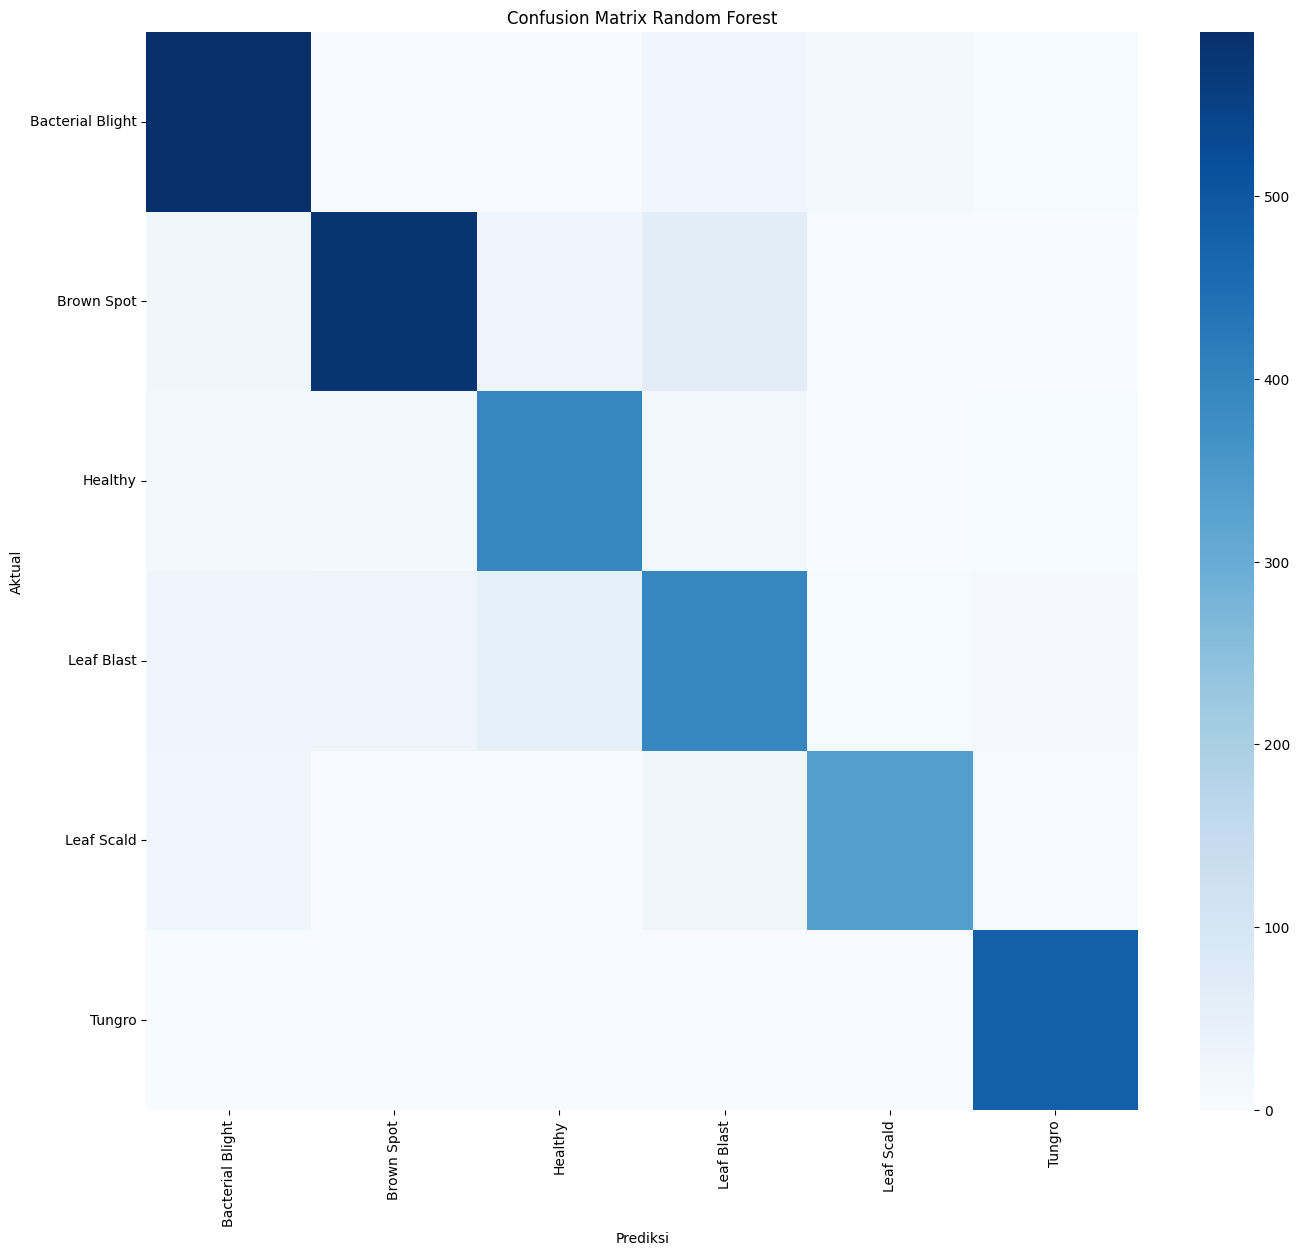

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(16,14))

sns.heatmap(
    cm,
    annot=False,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix Random Forest")

plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.savefig(
    "confusion_matrix.png",
    bbox_inches='tight'
)

plt.show()

## Visualisasi Hasil Prediksi

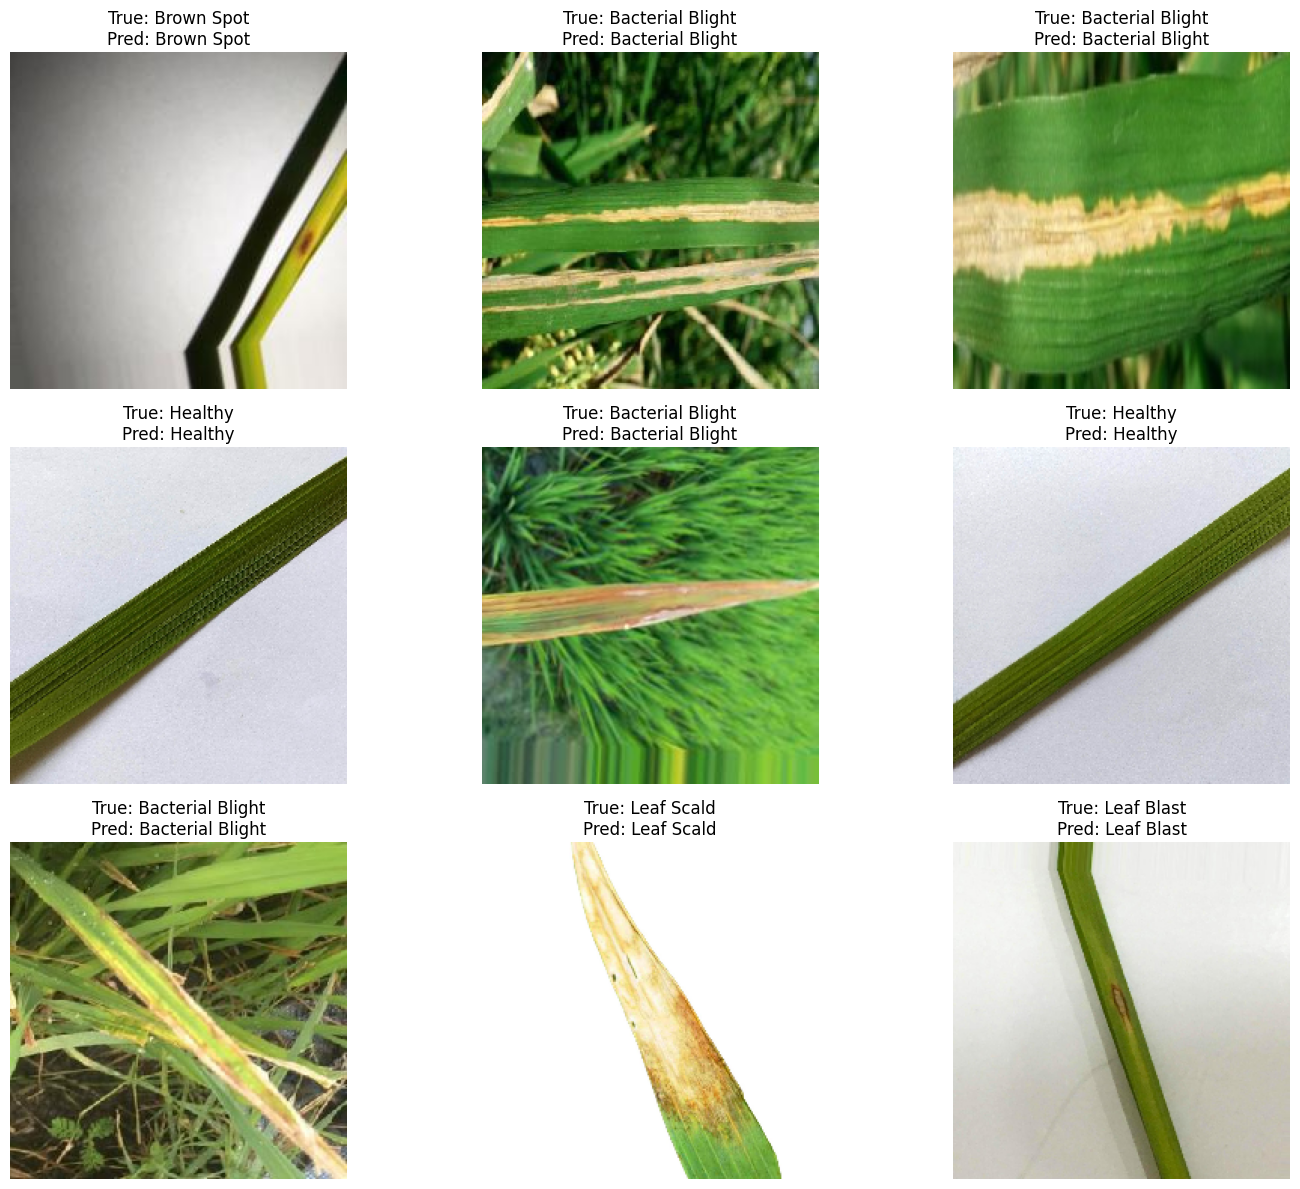

In [ ]:
plt.figure(figsize=(15,12))
for i in range(9):
    img_path = test_df.iloc[i]['filename']
    true_label = test_df.iloc[i]['label']
    img = load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    feature = base_model.predict(img_array, verbose=0)
    pred = rf.predict(feature)[0]
    pred_label = class_names[int(pred)]

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(
        f"True: {true_label}\nPred: {pred_label}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

## Visualisasi Metrik Evaluasi

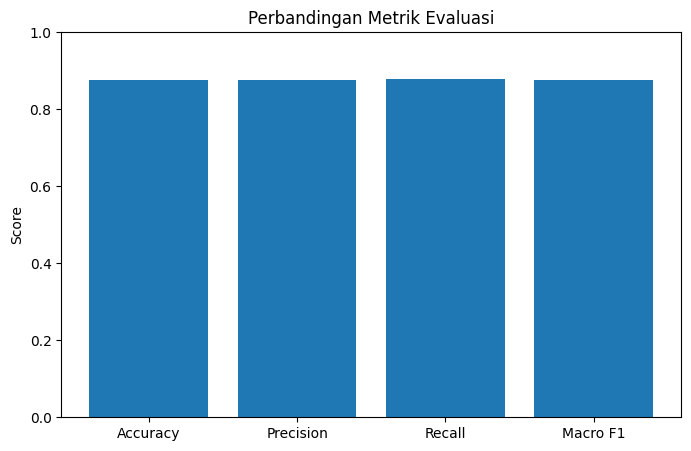

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'Macro F1']
scores = [acc, precision, recall, f1]
plt.figure(figsize=(8,5))
plt.bar(metrics, scores)
plt.ylim(0,1)
plt.title("Perbandingan Metrik Evaluasi")
plt.ylabel("Score")

plt.savefig(
    "evaluation_metrics.png",
    bbox_inches='tight'
)

plt.show()

# Feature Importance

In [ ]:
importance = rf.feature_importances_

feat_df = pd.DataFrame({
    'Feature': range(len(importance)),
    'Importance': importance
})

feat_df = feat_df.sort_values(
    by='Importance',
    ascending=False
)

print(feat_df.head(10))

     Feature  Importance
652      652    0.015442
298      298    0.010422
547      547    0.009967
687      687    0.008240
440      440    0.007700
107      107    0.006999
871      871    0.006926
15        15    0.006059
84        84    0.006035
158      158    0.006006


In [ ]:
feat_df.to_csv(
    "feature_importance.csv",
    index=False
)

print("Feature importance berhasil disimpan")

Feature importance berhasil disimpan


## Visualisasi Feature Importance

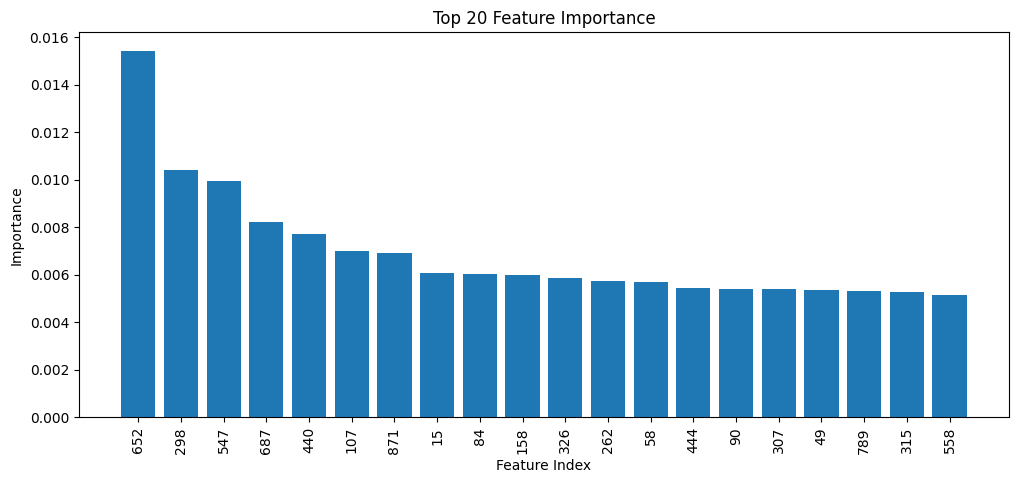

In [ ]:
top_features = feat_df.head(20)
plt.figure(figsize=(12,5))
plt.bar(
    top_features['Feature'].astype(str),
    top_features['Importance']
)

plt.title("Top 20 Feature Importance")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.xticks(rotation=90)

plt.savefig(
    "feature_importance.png",
    bbox_inches='tight'
)
plt.show()